# 02 Exploratory analysis and business findings

Revenue, spending, purchase frequency, cohorts, concentration, outliers and confidence intervals.

> Data: Online Retail II, UCI Machine Learning Repository (Chen, 2019, CC BY 4.0). Historical transactions from 1 Dec 2009 to 9 Dec 2011. This notebook reads the PostgreSQL tables produced by `gci import-data`, `gci build-analytics`, `gci build-features` and `gci train`; reusable logic lives in the `gci` package, not here.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import text
from gci.db.session import session_scope
from gci.api.sqlfiles import load_sql
sns.set_theme(style="whitegrid", palette=["#1D4ED8", "#94A3B8", "#0F1F3D", "#B45309"])
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
GBP = lambda v: f"£{v:,.0f}"

def q(sql, **params):
    with session_scope() as s:
        return pd.read_sql(text(sql) if isinstance(sql, str) else sql, s.connection(), params=params)

def findings(items):
    display(Markdown("\n".join(f"{i+1}. {t}" for i, t in enumerate(items))))

## 1. Revenue over time

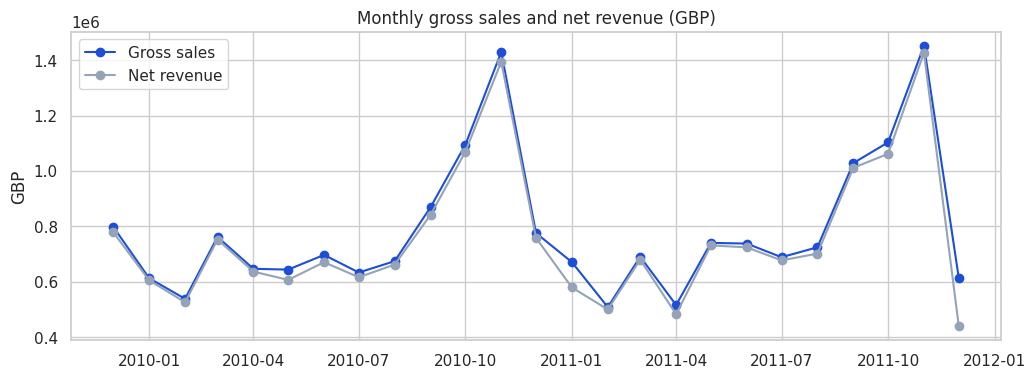

Note: December 2011 covers only 1-9 December.


year,2009,2010,2011
m,,,
1,NaN,"612,297.42","670,380.24"
2,NaN,"537,909.68","507,799.87"
3,NaN,"761,705.98","689,833.51"
4,NaN,"646,340.93","515,377.99"
5,NaN,"643,492.03","739,953.00"
6,NaN,"696,583.19","737,558.98"
7,NaN,"632,994.32","688,219.34"
8,NaN,"674,037.72","724,216.50"
9,NaN,"869,243.12","1,028,320.38"


In [2]:
trend = q(load_sql("monthly_revenue"), start_at="2009-12-01", end_at="2011-12-10")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trend.month, trend.gross_sales, marker="o", label="Gross sales"); ax.plot(trend.month, trend.net_revenue, marker="o", label="Net revenue")
ax.set_title("Monthly gross sales and net revenue (GBP)"); ax.legend(); ax.set_ylabel("GBP"); plt.show()
trend["month"] = pd.to_datetime(trend.month); trend["year"] = trend.month.dt.year; trend["m"] = trend.month.dt.month
print("Note: December 2011 covers only 1-9 December."); display(trend.pivot_table(index="m", columns="year", values="gross_sales"))

## 2. Distributions of order value and customer spending

Both are heavily right-skewed, so medians and log scales are used throughout.

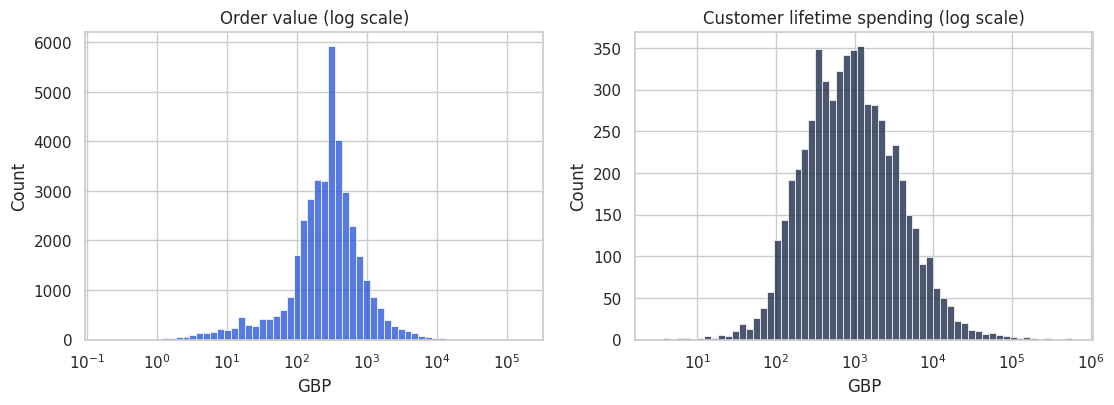

count    39,516.00
mean        497.11
std       1,460.34
min           0.19
50%         301.23
90%         905.56
99%       4,103.92
max     168,469.60

count     5,852.00
mean      2,916.71
std      14,306.87
min           2.95
50%         856.02
90%       5,392.77
99%      28,631.08
max     580,987.04


In [3]:
orders = q("SELECT gross_amount::float AS gross_amount, customer_id, order_at FROM orders WHERE is_eligible_positive")
cust = q("SELECT customer_id, gross_sales::float AS gross_sales, order_count, first_order_at, last_order_at FROM customers WHERE order_count > 0")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(orders.gross_amount, bins=60, log_scale=True, ax=axes[0], color="#1D4ED8"); axes[0].set_title("Order value (log scale)"); axes[0].set_xlabel("GBP")
sns.histplot(cust.gross_sales, bins=60, log_scale=True, ax=axes[1], color="#0F1F3D"); axes[1].set_title("Customer lifetime spending (log scale)"); axes[1].set_xlabel("GBP")
plt.show()
print(orders.gross_amount.describe(percentiles=[.5,.9,.99]).to_string()); print(); print(cust.gross_sales.describe(percentiles=[.5,.9,.99]).to_string())

## 3. Purchase frequency and intervals

,bucket,bucket_order,customers,share_pct
0,1 order,1,1618,27.60
1,2-3 orders,2,1604,27.40
2,4-9 orders,4,1669,28.50
3,10+ orders,10,961,16.40


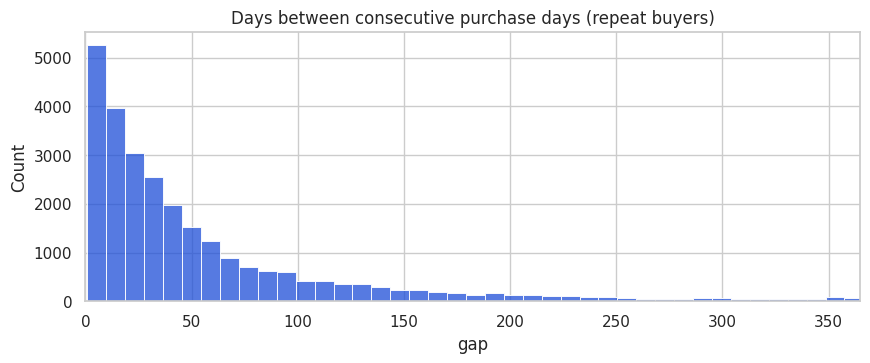

Median gap 32 days; 75th percentile 70 days; share of gaps within 30 days 49.0%


In [4]:
freq = q(load_sql("customer_purchase_frequency"), start_at="2009-12-01", end_at="2011-12-10"); display(freq)
o = orders.sort_values(["customer_id","order_at"]).copy(); o["day"] = pd.to_datetime(o.order_at).dt.normalize()
o = o.drop_duplicates(["customer_id","day"]); o["gap"] = o.groupby("customer_id").day.diff().dt.days
gaps = o.gap.dropna()
fig, ax = plt.subplots(figsize=(10, 3.5)); sns.histplot(gaps, bins=80, ax=ax, color="#1D4ED8"); ax.set_xlim(0, 365); ax.set_title("Days between consecutive purchase days (repeat buyers)"); plt.show()
print(f"Median gap {gaps.median():.0f} days; 75th percentile {gaps.quantile(.75):.0f} days; share of gaps within 30 days {(gaps<=30).mean():.1%}")

## 4. Cohort behaviour

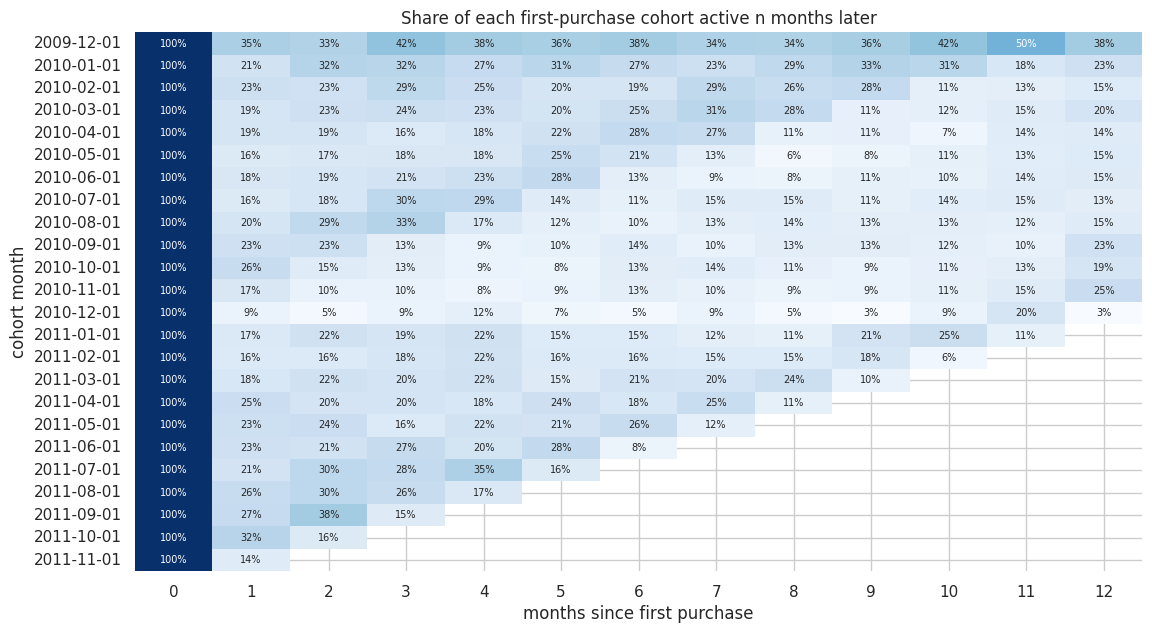

Cohort-size-weighted repeat rate one month after first purchase: 23.0%; three months after: 24.6%


In [5]:
coh = q(load_sql("cohort_repeat_rates"), start_month="2009-12-01", end_month="2011-11-01", max_months=12)
pivot = coh.pivot(index="cohort_month", columns="months_since_first", values="repeat_rate")
fig, ax = plt.subplots(figsize=(13, 7)); sns.heatmap(pivot, annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 7})
ax.set_title("Share of each first-purchase cohort active n months later"); ax.set_xlabel("months since first purchase"); ax.set_ylabel("cohort month"); plt.show()
m1 = coh[coh.months_since_first==1]; m3 = coh[coh.months_since_first==3]
print(f"Cohort-size-weighted repeat rate one month after first purchase: {np.average(m1.repeat_rate, weights=m1.cohort_size):.1%}; three months after: {np.average(m3.repeat_rate, weights=m3.cohort_size):.1%}")

## 5. Revenue concentration and country mix

In [6]:
dec = q(load_sql("revenue_contribution"), start_at="2009-12-01", end_at="2011-12-10"); display(dec)
countries = q("""SELECT coalesce(country,'Unknown') AS country, sum(gross_amount)::float AS gross_sales, count(DISTINCT customer_id) AS customers
                 FROM orders WHERE is_eligible_positive GROUP BY 1 ORDER BY 2 DESC LIMIT 10""")
countries["share"] = countries.gross_sales / countries.gross_sales.sum(); display(countries)

,decile,customers,gross_sales,revenue_share,cumulative_share
0,1,586,"10,905,365.83",0.64,0.64
1,2,586,"2,268,961.26",0.13,0.77
2,3,585,"1,328,783.11",0.08,0.85
3,4,585,"863,684.01",0.05,0.90
4,5,585,"598,331.86",0.04,0.94
5,6,585,"423,476.03",0.02,0.96
6,7,585,"290,265.25",0.02,0.98
7,8,585,"200,016.85",0.01,0.99
8,9,585,"127,480.30",0.01,1.00
9,10,585,"62,218.23",0.00,1.00


,country,gross_sales,customers,share
0,United Kingdom,"16,801,019.39",5334,0.88
1,EIRE,"623,414.16",3,0.03
2,Netherlands,"549,773.41",22,0.03
3,Germany,"383,289.00",107,0.02
4,France,"311,090.29",93,0.02
5,Australia,"167,800.01",15,0.01
6,Spain,"97,766.75",38,0.01
7,Switzerland,"94,024.59",22,0.00
8,Sweden,"86,319.14",19,0.00
9,Denmark,"67,422.69",12,0.00


## 6. Outlier investigation

A handful of lines dominate the tails. They are real records in the source (large wholesale orders, and one famous cancelled order), so they are kept but examined.

In [7]:
big = q("""SELECT t.invoice, t.customer_id, t.stock_code, t.description, t.quantity, t.unit_price::float AS unit_price, t.line_amount::float AS line_amount, t.invoice_date
            FROM transactions t WHERE t.is_eligible_sale ORDER BY t.line_amount DESC LIMIT 5"""); display(big)
cancelled = q("""SELECT invoice, customer_id, order_at, gross_amount::float AS gross_amount, return_amount::float AS return_amount
                 FROM orders WHERE customer_id = (SELECT customer_id FROM transactions WHERE is_eligible_sale ORDER BY line_amount DESC LIMIT 1) ORDER BY order_at"""); display(cancelled)
print("The largest single line was cancelled within the same day; net revenue treats the sale and the return as separate events on the dates they occurred.")

,invoice,customer_id,stock_code,description,quantity,unit_price,line_amount,invoice_date
0,581483,16446,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60",2011-12-09 09:15:00
1,541431,12346,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60",2011-01-18 10:01:00
2,556444,15098,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00",2011-06-10 15:28:00
3,530715,15838,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1.69,"15,818.40",2010-11-04 11:36:00
4,511465,18008,15044A,PINK PAPER PARASOL,3500,2.55,"8,925.00",2010-06-08 12:59:00


,invoice,customer_id,order_at,gross_amount,return_amount
0,C525275,16446,2010-10-04 16:38:00,0.00,0.00
1,553573,16446,2011-05-18 09:52:00,2.90,0.00
2,581483,16446,2011-12-09 09:15:00,"168,469.60",0.00
3,C581484,16446,2011-12-09 09:27:00,0.00,"-168,469.60"


The largest single line was cancelled within the same day; net revenue treats the sale and the return as separate events on the dates they occurred.


## 7. Confidence intervals for selected metrics

Customer-level bootstrap (customers resampled with replacement) for the 2011 repeat-purchase rate and the median order value.

In [8]:
rng = np.random.default_rng(42)
o11 = orders[(pd.to_datetime(orders.order_at) >= "2011-01-01") & (pd.to_datetime(orders.order_at) < "2011-12-10") & orders.customer_id.notna()]
per_c = o11.groupby("customer_id").agg(n=("gross_amount","size"), spend=("gross_amount","sum"))
def boot(stat, n=1000):
    vals = [stat(per_c.sample(frac=1, replace=True, random_state=int(rng.integers(1e9)))) for _ in range(n)]
    return np.percentile(vals, [2.5, 97.5])
rr = (per_c.n >= 2).mean(); rr_ci = boot(lambda d: (d.n >= 2).mean())
aov = o11.gross_amount.median(); aov_ci = np.percentile([o11.gross_amount.sample(frac=1, replace=True, random_state=i).median() for i in range(1000)], [2.5, 97.5])
print(f"2011 repeat-purchase rate: {rr:.1%} (95% CI {rr_ci[0]:.1%} to {rr_ci[1]:.1%}, n={len(per_c):,} customers)")
print(f"2011 median order value: {GBP(aov)} (95% CI {GBP(aov_ci[0])} to {GBP(aov_ci[1])}, n={len(o11):,} orders)")

2011 repeat-purchase rate: 64.1% (95% CI 62.7% to 65.7%, n=4,214 customers)
2011 median order value: £303 (95% CI £301 to £304, n=17,008 orders)


## 8. Findings

These are descriptive associations in historical data. None of them shows that an action (a campaign, a discount) caused a change in behaviour; that would require an experiment.

In [9]:
peak = trend.loc[trend.gross_sales.idxmax()]
findings([
 f"Sales are strongly seasonal: {peak.month:%B %Y} was the peak month with {GBP(peak.gross_sales)} in gross sales, and November is the top month in both full years.",
 f"Spending is concentrated: the top 10% of identified customers generated {dec.iloc[0].revenue_share:.0%} of identified gross sales; the median customer spent {GBP(cust.gross_sales.median())} in total.",
 f"{freq.set_index('bucket').loc['1 order','share_pct']:.0f}% of identified customers placed exactly one order over two years, while the 2011 repeat-purchase rate among 2011 buyers was {rr:.0%} (95% CI {rr_ci[0]:.0%}-{rr_ci[1]:.0%}).",
 f"Among repeat buyers the median gap between purchase days is {gaps.median():.0f} days and {(gaps<=30).mean():.0%} of gaps fall within 30 days, which is why a 30-day horizon is a meaningful prediction window.",
 f"The United Kingdom accounts for {countries.set_index('country').loc['United Kingdom','share']:.0%} of gross sales; the largest single line ({GBP(big.iloc[0].line_amount)}) was cancelled the same day, so raw sales overstate revenue unless returns are matched.",
])

1. Sales are strongly seasonal: November 2011 was the peak month with £1,452,116 in gross sales, and November is the top month in both full years.
2. Spending is concentrated: the top 10% of identified customers generated 64% of identified gross sales; the median customer spent £856 in total.
3. 28% of identified customers placed exactly one order over two years, while the 2011 repeat-purchase rate among 2011 buyers was 64% (95% CI 63%-66%).
4. Among repeat buyers the median gap between purchase days is 32 days and 49% of gaps fall within 30 days, which is why a 30-day horizon is a meaningful prediction window.
5. The United Kingdom accounts for 88% of gross sales; the largest single line (£168,470) was cancelled the same day, so raw sales overstate revenue unless returns are matched.